In [32]:
import pandas as pd
from matplotlib import pyplot as plt

from parallel_pandas import ParallelPandas

ParallelPandas.initialize(n_cpu=22, split_factor=2)

In [2]:
df_products = pd.read_csv('./data/data/products.csv', index_col='product_id')

df_clients = pd.read_csv('./data/data/clients.csv', index_col='client_id')
df_purchases = pd.read_csv('./data/data/purchases.csv', index_col='client_id')
df_train = pd.read_csv('./data/data/uplift_train.csv', index_col='client_id')
df_test = pd.read_csv('./data/data/uplift_test.csv', index_col='client_id')

In [3]:
print('df_clients shape: ', df_clients.shape)
print('df_products shape: ', df_products.shape)
print('df_purchases shape: ', df_purchases.shape)
print('df_train shape: ', df_train.shape)
print('df_test shape: ', df_test.shape)

df_clients shape:  (400162, 4)
df_products shape:  (43038, 10)
df_purchases shape:  (45786568, 12)
df_train shape:  (200039, 2)
df_test shape:  (200123, 0)


# CLIENTS

In [25]:
df_clients['first_issue_unixtime'] = pd.to_datetime(df_clients['first_issue_date']).astype('int64')/10**9
df_clients['first_redeem_unixtime'] = pd.to_datetime(df_clients['first_redeem_date']).astype('int64')/10**9
df_clients['issue_redeem_delay'] =  df_clients['first_redeem_unixtime'] - df_clients['first_issue_unixtime']
df_clients.drop(columns=['first_issue_date', 'first_redeem_date'], inplace=True)
df_clients

,age,gender,first_issue_unixtime,first_redeem_unixtime,issue_redeem_delay
client_id,,,,,
000012768d,45,U,1.501948e+09,1.515094e+09,1.314656e+07
000036f903,72,F,1.491832e+09,1.492951e+09,1.118613e+06
000048b7a6,68,F,1.544881e+09,-9.223372e+09,-1.076825e+10
000073194a,60,F,1.495544e+09,1.511522e+09,1.597811e+07
00007c7133,67,U,1.495470e+09,1.546277e+09,5.080682e+07
...,...,...,...,...,...
fffece623e,67,U,1.526224e+09,1.545938e+09,1.971343e+07
ffff3dfff8,56,F,1.541088e+09,1.544204e+09,3.115615e+06
ffffaab9da,23,F,1.503687e+09,1.512756e+09,9.068995e+06


In [26]:
df_clients.info()

<class 'pandas.core.frame.DataFrame'>
Index: 400162 entries, 000012768d to fffff6ce77
Data columns (total 5 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   age                    400162 non-null  int64  
 1   gender                 400162 non-null  object 
 2   first_issue_unixtime   400162 non-null  float64
 3   first_redeem_unixtime  400162 non-null  float64
 4   issue_redeem_delay     400162 non-null  float64
dtypes: float64(3), int64(1), object(1)
memory usage: 18.3+ MB


C:\Users\Евгений\AppData\Local\Temp\ipykernel_17772\800789566.py:15: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


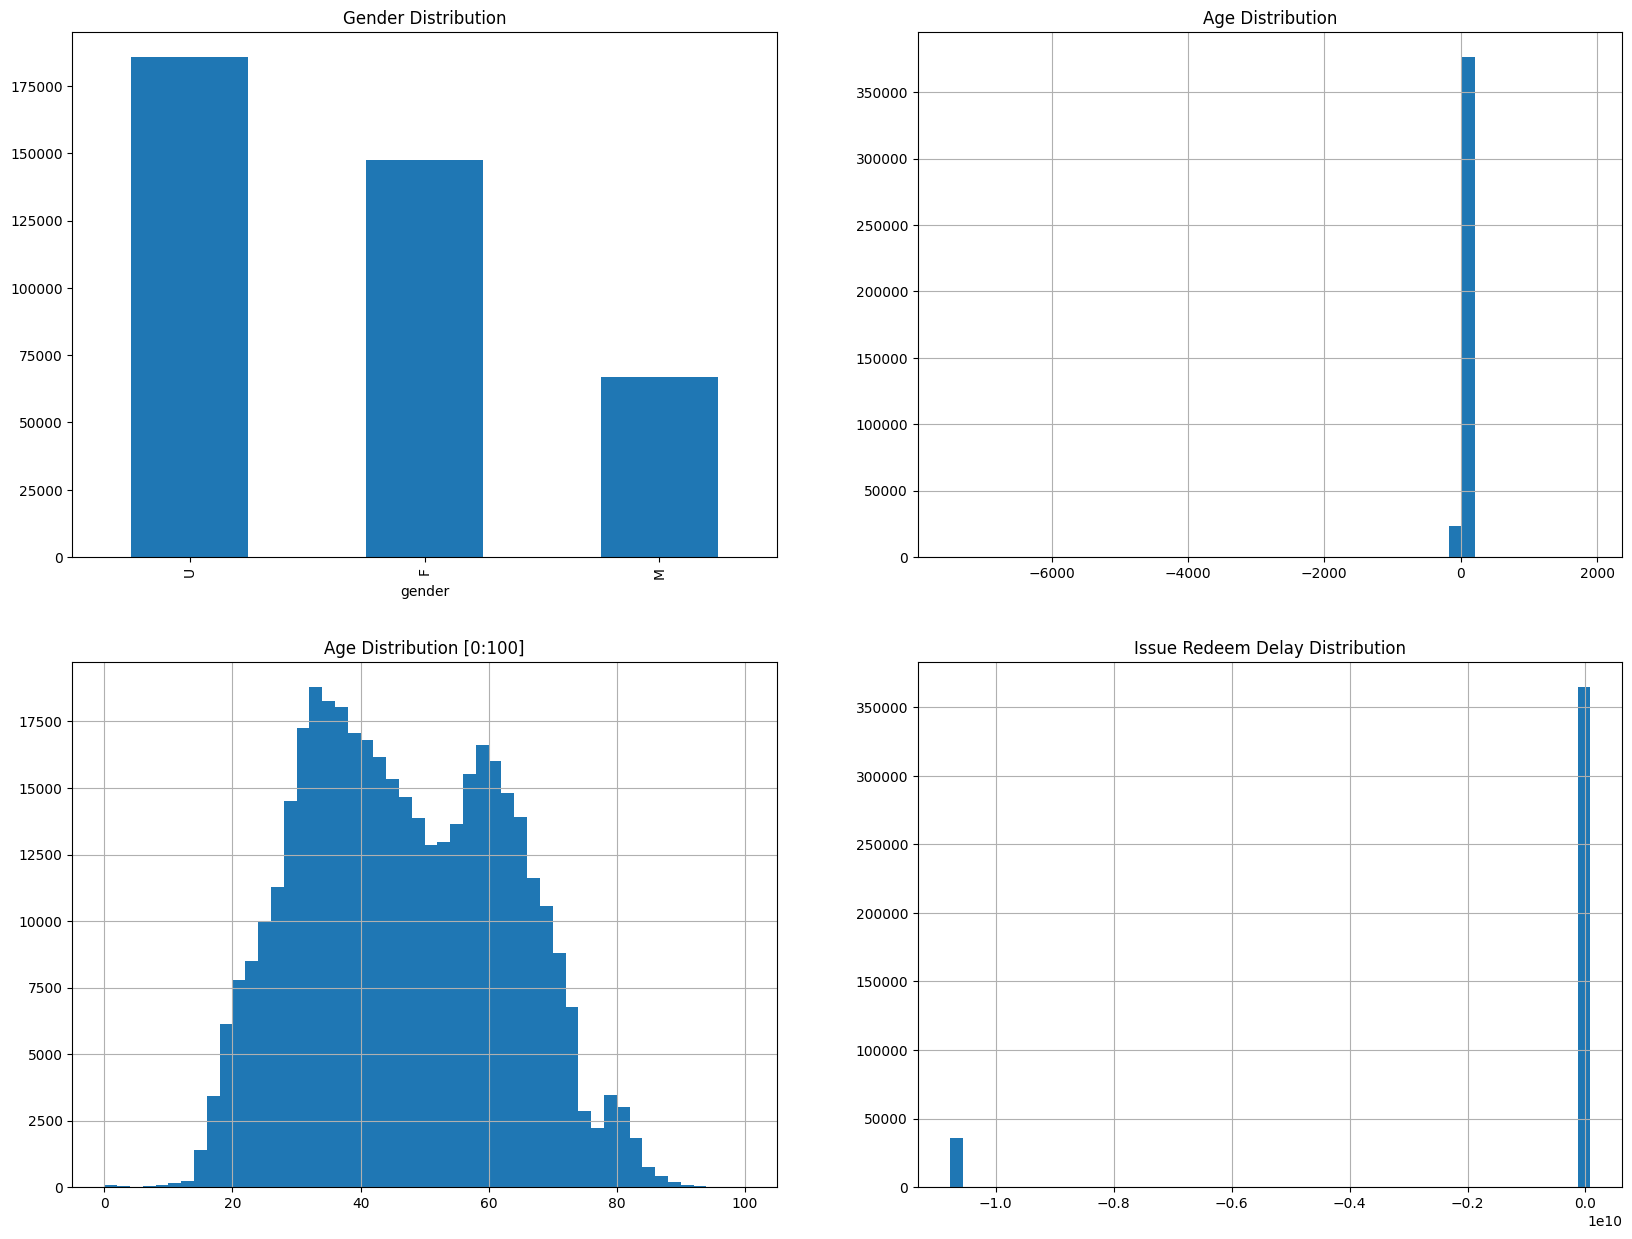

In [27]:
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(20, 15))

df_clients['gender'].value_counts().plot.bar(ax=axs[0, 0])
axs[0, 0].set_title('Gender Distribution')

df_clients['age'].hist(bins=50, ax=axs[0, 1])
axs[0, 1].set_title('Age Distribution')

df_clients.loc[(df_clients.age >= 0) & (df_clients.age <= 100)]['age'].hist(bins=50, ax=axs[1, 0])
axs[1, 0].set_title('Age Distribution [0:100]')

df_clients['issue_redeem_delay'].hist(bins=50, ax=axs[1, 1])
axs[1, 1].set_title('Issue Redeem Delay Distribution')

fig.show()

In [28]:
df_clients['age_oon'] = (df_clients['age'] < 0) | (df_clients['age'] > 100)
df_clients['issue_redeem_delay_oon'] = df_clients['issue_redeem_delay'] < 0.1

# PRODUCTS

In [8]:
df_products

,level_1,level_2,level_3,level_4,segment_id,brand_id,vendor_id,netto,is_own_trademark,is_alcohol
product_id,,,,,,,,,,
0003020d3c,c3d3a8e8c6,c2a3ea8d5e,b7cda0ec0c,6376f2a852,123.0,394a54a7c1,9eaff48661,0.400,0,0
0003870676,e344ab2e71,52f13dac0c,d3cfe81323,6dc544533f,105.0,acd3dd483f,10486c3cf0,0.680,0,0
0003ceaf69,c3d3a8e8c6,f2333c90fb,419bc5b424,f6148afbc0,271.0,f597581079,764e660dda,0.500,0,0
000701e093,ec62ce61e3,4202626fcb,88a515c084,48cf3d488f,172.0,54a90fe769,03c2d70bad,0.112,0,0
0007149564,e344ab2e71,52f13dac0c,d3cfe81323,6dc544533f,105.0,63417fe1f3,f329130198,0.600,0,0
...,...,...,...,...,...,...,...,...,...,...
fffac3a287,e344ab2e71,52f13dac0c,0f84eb7480,420c3b3f0b,150.0,5aef526287,f546d8aa6f,0.085,0,0
fffd2946cf,e344ab2e71,52f13dac0c,a1786084ca,b2960bceb8,176.0,7bf16d4aa4,3d8c5ef5f4,0.130,0,0
fffd7fb409,e344ab2e71,1d2939ba1d,2721c4b3d6,32f03574dd,255.0,1267326e16,0cfa052441,0.450,0,0


In [9]:
df_products.reset_index(inplace=True)
df_products.dropna(how='any', subset=['level_1', 'vendor_id', 'netto'], inplace=True)
df_products.drop_duplicates(keep='first', inplace=True)

In [10]:
df_products

,product_id,level_1,level_2,level_3,level_4,segment_id,brand_id,vendor_id,netto,is_own_trademark,is_alcohol
0,0003020d3c,c3d3a8e8c6,c2a3ea8d5e,b7cda0ec0c,6376f2a852,123.0,394a54a7c1,9eaff48661,0.400,0,0
1,0003870676,e344ab2e71,52f13dac0c,d3cfe81323,6dc544533f,105.0,acd3dd483f,10486c3cf0,0.680,0,0
2,0003ceaf69,c3d3a8e8c6,f2333c90fb,419bc5b424,f6148afbc0,271.0,f597581079,764e660dda,0.500,0,0
3,000701e093,ec62ce61e3,4202626fcb,88a515c084,48cf3d488f,172.0,54a90fe769,03c2d70bad,0.112,0,0
4,0007149564,e344ab2e71,52f13dac0c,d3cfe81323,6dc544533f,105.0,63417fe1f3,f329130198,0.600,0,0
...,...,...,...,...,...,...,...,...,...,...,...
43033,fffac3a287,e344ab2e71,52f13dac0c,0f84eb7480,420c3b3f0b,150.0,5aef526287,f546d8aa6f,0.085,0,0
43034,fffd2946cf,e344ab2e71,52f13dac0c,a1786084ca,b2960bceb8,176.0,7bf16d4aa4,3d8c5ef5f4,0.130,0,0
43035,fffd7fb409,e344ab2e71,1d2939ba1d,2721c4b3d6,32f03574dd,255.0,1267326e16,0cfa052441,0.450,0,0
43036,fffd963a2c,c3d3a8e8c6,c2a3ea8d5e,a6b0dd76e0,a7e8f1cc02,220.0,c2eec3be6f,75ea3d1182,0.300,0,0


In [11]:
df_productslambda x: x.nunique()().plot.bar(title='Field Unique Values Num')

SyntaxError: invalid syntax (1717056129.py, line 1)

# PURCHASES

In [12]:
df_purchases.reset_index(inplace=True)
df_purchases

,client_id,transaction_id,transaction_datetime,regular_points_received,express_points_received,regular_points_spent,express_points_spent,purchase_sum,store_id,product_id,product_quantity,trn_sum_from_iss,trn_sum_from_red
0,000012768d,7e3e2e3984,2018-12-01 07:12:45,10.0,0.0,0.0,0.0,1007.0,54a4a11a29,9a80204f78,2.0,80.0,NaN
1,000012768d,7e3e2e3984,2018-12-01 07:12:45,10.0,0.0,0.0,0.0,1007.0,54a4a11a29,da89ebd374,1.0,65.0,NaN
2,000012768d,7e3e2e3984,2018-12-01 07:12:45,10.0,0.0,0.0,0.0,1007.0,54a4a11a29,0a95e1151d,1.0,24.0,NaN
3,000012768d,7e3e2e3984,2018-12-01 07:12:45,10.0,0.0,0.0,0.0,1007.0,54a4a11a29,4055b15e4a,2.0,50.0,NaN
4,000012768d,7e3e2e3984,2018-12-01 07:12:45,10.0,0.0,0.0,0.0,1007.0,54a4a11a29,a685f1916b,1.0,22.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
45786563,fffff6ce77,48f6d115ce,2019-03-15 17:47:02,6.7,0.0,0.0,0.0,676.0,5ec64bdccb,24d5a54f42,1.0,164.0,NaN
45786564,fffff6ce77,48f6d115ce,2019-03-15 17:47:02,6.7,0.0,0.0,0.0,676.0,5ec64bdccb,7427d0830d,1.0,134.0,NaN
45786565,fffff6ce77,48f6d115ce,2019-03-15 17:47:02,6.7,0.0,0.0,0.0,676.0,5ec64bdccb,6c547c2ca8,1.0,60.0,NaN
45786566,fffff6ce77,48f6d115ce,2019-03-15 17:47:02,6.7,0.0,0.0,0.0,676.0,5ec64bdccb,d04e7a8338,1.0,48.0,NaN


In [13]:
df_purchases.info(verbose=True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45786568 entries, 0 to 45786567
Data columns (total 13 columns):
 #   Column                   Non-Null Count     Dtype  
---  ------                   --------------     -----  
 0   client_id                45786568 non-null  object 
 1   transaction_id           45786568 non-null  object 
 2   transaction_datetime     45786568 non-null  object 
 3   regular_points_received  45786568 non-null  float64
 4   express_points_received  45786568 non-null  float64
 5   regular_points_spent     45786568 non-null  float64
 6   express_points_spent     45786568 non-null  float64
 7   purchase_sum             45786568 non-null  float64
 8   store_id                 45786568 non-null  object 
 9   product_id               45786568 non-null  object 
 10  product_quantity         45786568 non-null  float64
 11  trn_sum_from_iss         45786568 non-null  float64
 12  trn_sum_from_red         3043356 non-null   float64
dtypes: float64(8), object(5)


In [14]:
print(df_purchases['transaction_datetime'].min(), df_purchases['transaction_datetime'].max())

2018-11-21 21:02:33 2019-03-18 23:40:03


# PRODUCTS_PURCHASES

In [15]:
product_purchases = pd.merge(
    df_purchases,
    df_products,
    on='product_id',
    how='inner'
)

In [16]:
product_purchases.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45777858 entries, 0 to 45777857
Data columns (total 23 columns):
 #   Column                   Dtype  
---  ------                   -----  
 0   client_id                object 
 1   transaction_id           object 
 2   transaction_datetime     object 
 3   regular_points_received  float64
 4   express_points_received  float64
 5   regular_points_spent     float64
 6   express_points_spent     float64
 7   purchase_sum             float64
 8   store_id                 object 
 9   product_id               object 
 10  product_quantity         float64
 11  trn_sum_from_iss         float64
 12  trn_sum_from_red         float64
 13  level_1                  object 
 14  level_2                  object 
 15  level_3                  object 
 16  level_4                  object 
 17  segment_id               float64
 18  brand_id                 object 
 19  vendor_id                object 
 20  netto                    float64
 21  is_own

In [18]:
product_purchases_by_client = product_purchases.groupby('client_id').agg({
    'transaction_id': lambda x: x.nunique(),
    'regular_points_received': ['sum', 'mean'],
    'express_points_received': ['sum', 'mean'],
    'regular_points_spent': ['sum', 'mean'],
    'express_points_spent': ['sum', 'mean'],
    'purchase_sum': ['sum', 'mean'],
    'store_id': lambda x: x.nunique(),
    'level_1': lambda x: x.nunique(),
    'level_2': lambda x: x.nunique(),
    'level_3': lambda x: x.nunique(),
    'level_4': lambda x: x.nunique(),
    'segment_id': lambda x: x.nunique(),
    'brand_id': lambda x: x.nunique(),
    'vendor_id': lambda x: x.nunique(),
    'is_own_trademark': ['count', lambda x: x.nunique()],
    'is_alcohol': ['count', lambda x: x.nunique()]
})
product_purchases_by_client.columns = [x[0]+'_'+x[1].replace('<lambda>', 'nunique').replace('<lambda_0>','nunique') for x in product_purchases_by_client.columns]
product_purchases_by_client.columns

In [21]:
product_purchases_by_client

,transaction_id_nunique,regular_points_received_sum,regular_points_received_mean,express_points_received_sum,express_points_received_mean,regular_points_spent_sum,regular_points_spent_mean,express_points_spent_sum,express_points_spent_mean,purchase_sum_sum,...,level_2_nunique,level_3_nunique,level_4_nunique,segment_id_nunique,brand_id_nunique,vendor_id_nunique,is_own_trademark_count,is_own_trademark_nunique,is_alcohol_count,is_alcohol_nunique
client_id,,,,,,,,,,,,,,,,,,,,,
000012768d,4,392.7,7.551923,0.0,0.000000,0.0,0.000000,0.0,0.0,40809.00,...,8,24,31,23,28,29,52,2,52,1
000036f903,32,348.3,2.150000,360.0,2.222222,0.0,0.000000,0.0,0.0,58765.00,...,12,39,58,41,51,44,162,2,162,2
000048b7a6,8,218.8,3.907143,0.0,0.000000,0.0,0.000000,0.0,0.0,29724.00,...,10,16,20,16,21,21,56,2,56,1
000073194a,17,518.8,6.326829,0.0,0.000000,-576.0,-7.024390,0.0,0.0,62719.92,...,14,35,45,27,42,42,82,2,82,2
00007c7133,11,459.7,5.538554,0.0,0.000000,-1680.0,-20.240964,0.0,0.0,53998.72,...,14,33,44,34,33,32,83,2,83,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
fffece623e,24,287.8,2.459829,0.0,0.000000,-544.0,-4.649573,0.0,0.0,43103.46,...,13,37,56,42,47,42,117,2,117,2
ffff3dfff8,17,1040.7,10.840625,0.0,0.000000,-728.0,-7.583333,0.0,0.0,65810.71,...,15,43,61,43,58,44,96,2,96,2
ffffaab9da,7,387.9,6.574576,0.0,0.000000,-60.0,-1.016949,0.0,0.0,40386.00,...,13,26,33,26,31,26,59,2,59,1


# ASSEMBLE DATASET

In [22]:
df_clients.info()

<class 'pandas.core.frame.DataFrame'>
Index: 400162 entries, 000012768d to fffff6ce77
Data columns (total 8 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   first_issue_date        400162 non-null  object 
 1   age                     400162 non-null  int64  
 2   gender                  400162 non-null  object 
 3   first_issue_unixtime    400162 non-null  float64
 4   first_redeem_unixtime   400162 non-null  float64
 5   issue_redeem_delay      400162 non-null  float64
 6   age_oon                 400162 non-null  bool   
 7   issue_redeem_delay_oon  400162 non-null  bool   
dtypes: bool(2), float64(3), int64(1), object(2)
memory usage: 30.2+ MB


In [29]:
dataset = df_clients.merge(
    product_purchases_by_client,
    left_index=True,
    right_index=True,
    how='inner'
)
dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 400162 entries, 000012768d to fffff6ce77
Data columns (total 30 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   age                           400162 non-null  int64  
 1   gender                        400162 non-null  object 
 2   first_issue_unixtime          400162 non-null  float64
 3   first_redeem_unixtime         400162 non-null  float64
 4   issue_redeem_delay            400162 non-null  float64
 5   age_oon                       400162 non-null  bool   
 6   issue_redeem_delay_oon        400162 non-null  bool   
 7   transaction_id_nunique        400162 non-null  int64  
 8   regular_points_received_sum   400162 non-null  float64
 9   regular_points_received_mean  400162 non-null  float64
 10  express_points_received_sum   400162 non-null  float64
 11  express_points_received_mean  400162 non-null  float64
 12  regular_points_spent_sum      400162

In [30]:
dataset

,age,gender,first_issue_unixtime,first_redeem_unixtime,issue_redeem_delay,age_oon,issue_redeem_delay_oon,transaction_id_nunique,regular_points_received_sum,regular_points_received_mean,...,level_2_nunique,level_3_nunique,level_4_nunique,segment_id_nunique,brand_id_nunique,vendor_id_nunique,is_own_trademark_count,is_own_trademark_nunique,is_alcohol_count,is_alcohol_nunique
client_id,,,,,,,,,,,,,,,,,,,,,
000012768d,45,U,1.501948e+09,1.515094e+09,1.314656e+07,False,False,4,392.7,7.551923,...,8,24,31,23,28,29,52,2,52,1
000036f903,72,F,1.491832e+09,1.492951e+09,1.118613e+06,False,False,32,348.3,2.150000,...,12,39,58,41,51,44,162,2,162,2
000048b7a6,68,F,1.544881e+09,-9.223372e+09,-1.076825e+10,False,True,8,218.8,3.907143,...,10,16,20,16,21,21,56,2,56,1
000073194a,60,F,1.495544e+09,1.511522e+09,1.597811e+07,False,False,17,518.8,6.326829,...,14,35,45,27,42,42,82,2,82,2
00007c7133,67,U,1.495470e+09,1.546277e+09,5.080682e+07,False,False,11,459.7,5.538554,...,14,33,44,34,33,32,83,2,83,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
fffece623e,67,U,1.526224e+09,1.545938e+09,1.971343e+07,False,False,24,287.8,2.459829,...,13,37,56,42,47,42,117,2,117,2
ffff3dfff8,56,F,1.541088e+09,1.544204e+09,3.115615e+06,False,False,17,1040.7,10.840625,...,15,43,61,43,58,44,96,2,96,2
ffffaab9da,23,F,1.503687e+09,1.512756e+09,9.068995e+06,False,False,7,387.9,6.574576,...,13,26,33,26,31,26,59,2,59,1


In [33]:
dataset.to_parquet('./data/preprocessed/dataset_v0.parquet')